### Tasks

1. Base EDA and data preprocessing: (+3)
a. clarify the meaning of features you are going to exploit
b. Execute the correlation analysis of variables, try to establish dependent ones
c. Perform feature selection
d. Perform data preprocessing (encode your features in some way, different types of encoding may dramatically affect your model, be selective, try multiple (at leas 2) ways)

2. Try at least 3 different types of models (+2)

3. Try an ensemble model with trainable and non-trainable weights. (+2)

4. Make explainable model (+2)

5. Aggregate the results, proceed the error analysis, compare the models (+1)

6. *Try NN approach for the task (+1)

In [1]:
import pandas as pd
import missingno
import seaborn as sns
import matplotlib.pyplot as plt

import h2o
from h2o.automl import H2OAutoML

from utils import save_submission
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

DATA_FOLDER = "data/"
OUTPUT_FOLDER = "outputs/"

In [2]:
train = pd.read_csv(DATA_FOLDER + "train.csv").drop(columns=["Unnamed: 0"])
train.head(5)

,Grade,Case_ID,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,GBM,TCGA-06-A6S0,Male,79 years 183 days,Glioblastoma,black or african american,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,LGG,TCGA-HT-8106,Male,53 years 197 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
2,LGG,TCGA-HT-7607,Female,61 years 305 days,"Astrocytoma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,LGG,TCGA-QH-A6X5,Female,58 years 55 days,Mixed glioma,white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
4,LGG,TCGA-P5-A5F1,Male,30 years 113 days,"Astrocytoma, NOS",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


### EDA

In [3]:
print("Shape of train data", train.shape)
print("Number of duplicates", train.duplicated().sum())
print("Unique values of each column:", pd.DataFrame(train.nunique()).T.to_markdown(), sep="\n")

Shape of train data (603, 26)
Number of duplicates 0
Unique values of each column:
|    |   Grade |   Case_ID |   Gender |   Age_at_diagnosis |   Primary_Diagnosis |   Race |   IDH1 |   TP53 |   ATRX |   PTEN |   EGFR |   CIC |   MUC16 |   PIK3CA |   NF1 |   PIK3R1 |   FUBP1 |   RB1 |   NOTCH1 |   BCOR |   CSMD3 |   SMARCA4 |   GRIN2A |   IDH2 |   FAT4 |   PDGFRA |
|---:|--------:|----------:|---------:|-------------------:|--------------------:|-------:|-------:|-------:|-------:|-------:|-------:|------:|--------:|---------:|------:|---------:|--------:|------:|---------:|-------:|--------:|----------:|---------:|-------:|-------:|---------:|
|  0 |       2 |       603 |        3 |                595 |                   7 |      6 |      2 |      2 |      2 |      2 |      2 |     2 |       2 |        2 |     2 |        2 |       2 |     2 |        2 |      2 |       2 |         2 |        2 |      2 |      2 |        2 |


['black or african american' 'white' 'not reported' 'asian' '--'
 'american indian or alaska native']
['Male' 'Female' '--']
['Glioblastoma' 'Astrocytoma, anaplastic' 'Astrocytoma, NOS'
 'Mixed glioma' 'Oligodendroglioma, anaplastic' 'Oligodendroglioma, NOS'
 '--']


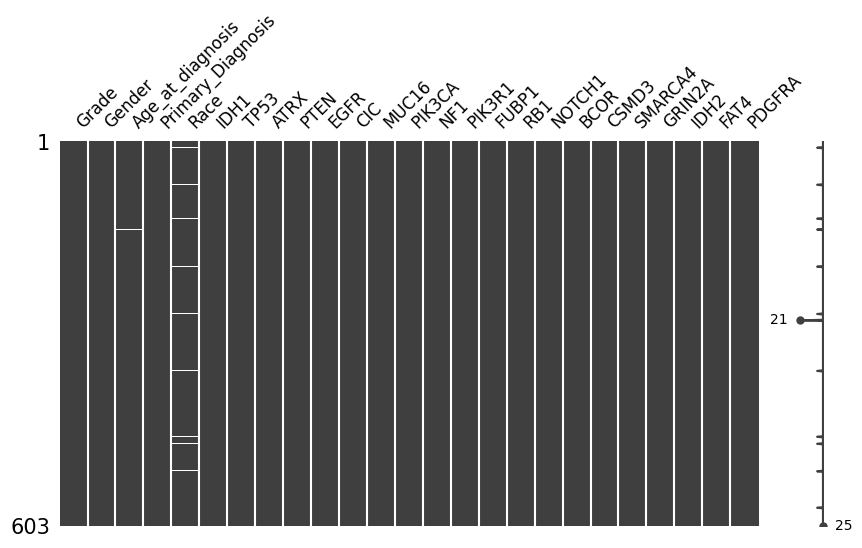

In [4]:
train = train.drop(columns=["Case_ID"])
print(train["Race"].unique(), train["Gender"].unique(), train["Primary_Diagnosis"].unique(), sep="\n")

train = train.replace({"--": None, "not reported": None})
# in 22 colums values is always set. total columns: 26
missingno.matrix(train, figsize=(10,5), fontsize=12);

In [5]:
train = train.fillna(-1)
train["Age_at_diagnosis"] = train["Age_at_diagnosis"].apply(lambda x: int(x.split(" ")[0]) if isinstance(x, str) else x)

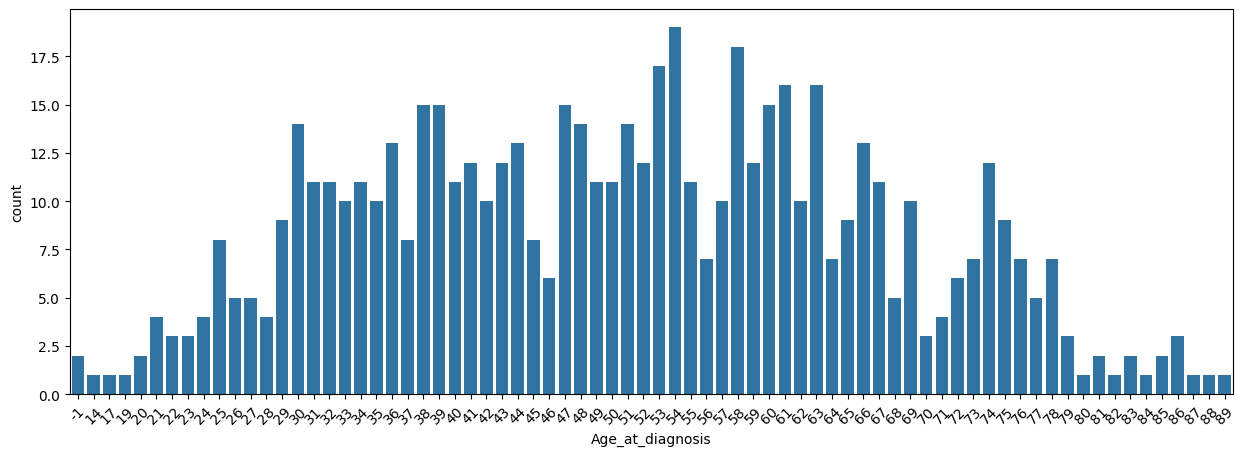

In [142]:
plt.figure(figsize=(15, 5))
sns.countplot(data=train.sort_values(by="Age_at_diagnosis"), x="Age_at_diagnosis")
plt.xticks(rotation=45);

### Make prediction

In [6]:
test = pd.read_csv(DATA_FOLDER + "test.csv").drop(columns=["Unnamed: 0"])
test.head(5)

,Case_ID,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,TCGA-DU-A5TW,Female,33 years 54 days,"Astrocytoma, anaplastic",black or african american,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,TCGA-DU-7007,Male,33 years 192 days,"Astrocytoma, NOS",white,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
2,TCGA-P5-A5EZ,Male,39 years 131 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,TCGA-02-0055,Female,62 years 153 days,Glioblastoma,white,NOT_MUTATED,MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
4,TCGA-28-5218,Male,63 years 86 days,Glioblastoma,white,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


### AutoML

In [8]:
h2o.init()
# data = h2o.import_file(DATA_FOLDER+"train.csv")
# data = h2o.H2OFrame(train)

# train, test = data.split_frame(ratios=[0.8])
train_data = h2o.H2OFrame(train)

y ="Grade"
x = train_data.columns
x.remove(y)

aml = H2OAutoML(max_runtime_secs=180)

aml.train(x=x, y=y, training_frame=train_data)

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,7 hours 53 mins
H2O_cluster_timezone:,Europe/Moscow
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.5
H2O_cluster_version_age:,15 days
H2O_cluster_name:,H2O_from_python_susbar_0stp5v
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.354 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2ODeepLearningEstimator : Deep Learning
Model Key: DeepLearning_grid_1_AutoML_5_20240913_171359_model_2


Status of Neuron Layers: predicting Grade, 2-class classification, bernoulli distribution, CrossEntropy loss, 1,642 weights/biases, 25.5 KB, 1,435,140 training samples, mini-batch size 1
    layer    units    type              dropout    l1    l2    mean_rate            rate_rms             momentum    mean_weight           weight_rms          mean_bias              bias_rms
--  -------  -------  ----------------  ---------  ----  ----  -------------------  -------------------  ----------  --------------------  ------------------  ---------------------  -------------------
    1        79       Input             15.0
    2        20       RectifierDropout  40.0       0.0   0.0   0.33964233746906597  0.45826900005340576  0.0         0.019821076521806896  0.2993229627609253  0.33167328269751295    0.07953429222106934
    3        2        Softmax                      0.0   0.0   0.07615379372873576  0.20774275064468384  0.0         0.13647225168533622   1.5950937271118164  -0.008805409506823292  0.6565079689025879

ModelMetricsBinomial: deeplearning
** Reported on train data. **

MSE: 2.1090171089350168e-07
RMSE: 0.00045924036287493466
LogLoss: 2.146601228165413e-05
Mean Per-Class Error: 0.0
AUC: 1.0
AUCPR: 1.0
Gini: 1.0

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.9992503979042775
       GBM    LGG    Error    Rate
-----  -----  -----  -------  -----------
GBM    254    0      0        (0.0/254.0)
LGG    0      349    0        (0.0/349.0)
Total  254    349    0        (0.0/603.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value      idx
---------------------------  -----------  ---------  -----
max f1                       0.99925      1          20
max f2                       0.99925      1          20
max f0point5                 0.99925      1          20
max accuracy                 0.99925      1          20
max precision                1            1          0
max recall                   0.99925      1          20
max specificity              1            1          0
max absolute_mcc             0.99925      1          20
max min_per_class_accuracy   0.99925      1          20
max mean_per_class_accuracy  0.99925      1          20
max tns                      1            254        0
max fns                      1            30         0
max fps                      8.20224e-21  254        265
max tps                      0.99925      349        20
max tnr                      1            1          0
max fnr                      1            0.0859599  0
max fpr                      8.20224e-21  1          265
max tpr                      0.99925      1          20

Gains/Lift Table: Avg response rate: 57.88 %, avg score: 57.88 %
group    cumulative_data_fraction    lower_threshold    lift     cumulative_lift    response_rate    score        cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain     cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  -------  -----------------  ---------------  -----------  --------------------------  ------------------  --------------  -------------------------  -------  -----------------  --------------------
1        0.107794                    1                  1.72779  1.72779            1                1            1                           1                   0.186246        0.186246                   72.7794  72.7794            0.186246
2        0.150912                    1                  1.72779  1.72779            1                1            1                           1                   0.0744986       0.260745                   72.7794  72.7794            0.260745
3        0.200663                    1                  1.72779  1.72779            1                1       

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
XGBoost_grid_1_AutoML_5_20240913_171359_model_22,1,0.009444,1,0,0.0369534,0.00136556,527,0.024188,XGBoost
GBM_4_AutoML_5_20240913_171359,1,3.408e-16,1,0,7.50638e-16,5.63457e-31,1970,0.578254,GBM
StackedEnsemble_BestOfFamily_2_AutoML_5_20240913_171359,1,3.96704e-06,1,0,4.44206e-06,1.97319e-11,756,0.574735,StackedEnsemble
GBM_grid_1_AutoML_5_20240913_171359_model_6,1,6.60194e-12,1,0,1.27854e-10,1.63467e-20,1877,0.650178,GBM
GBM_grid_1_AutoML_5_20240913_171359_model_8,1,3.57628e-15,1,0,3.61805e-15,1.30903e-29,722,0.405712,GBM
StackedEnsemble_BestOfFamily_4_AutoML_5_20240913_171359,1,0.000619297,1,0,0.0026557,7.05272e-06,523,0.548272,StackedEnsemble
GBM_grid_1_AutoML_5_20240913_171359_model_10,1,0.00259726,1,0,0.00262324,6.88141e-06,101,0.099123,GBM
XGBoost_grid_1_AutoML_5_20240913_171359_model_23,1,0.0184068,1,0,0.0461097,0.0021261,717,0.015,XGBoost
DeepLearning_grid_1_AutoML_5_20240913_171359_model_2,1,2.1466e-05,1,0,0.00045924,2.10902e-07,1578,0.017557,DeepLearning
GBM_grid_1_AutoML_5_20240913_171359_model_5,1,1.04726e-15,1,0,2.32357e-15,5.39897e-30,1533,0.647208,GBM


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## DeepLearning_grid_1_AutoML_5_20240913_171359_model_2

,GBM,LGG,Error,Rate
GBM,254.0,0.0,0.0,(0.0/254.0)
LGG,0.0,349.0,0.0,(0.0/349.0)
Total,254.0,349.0,0.0,(0.0/603.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

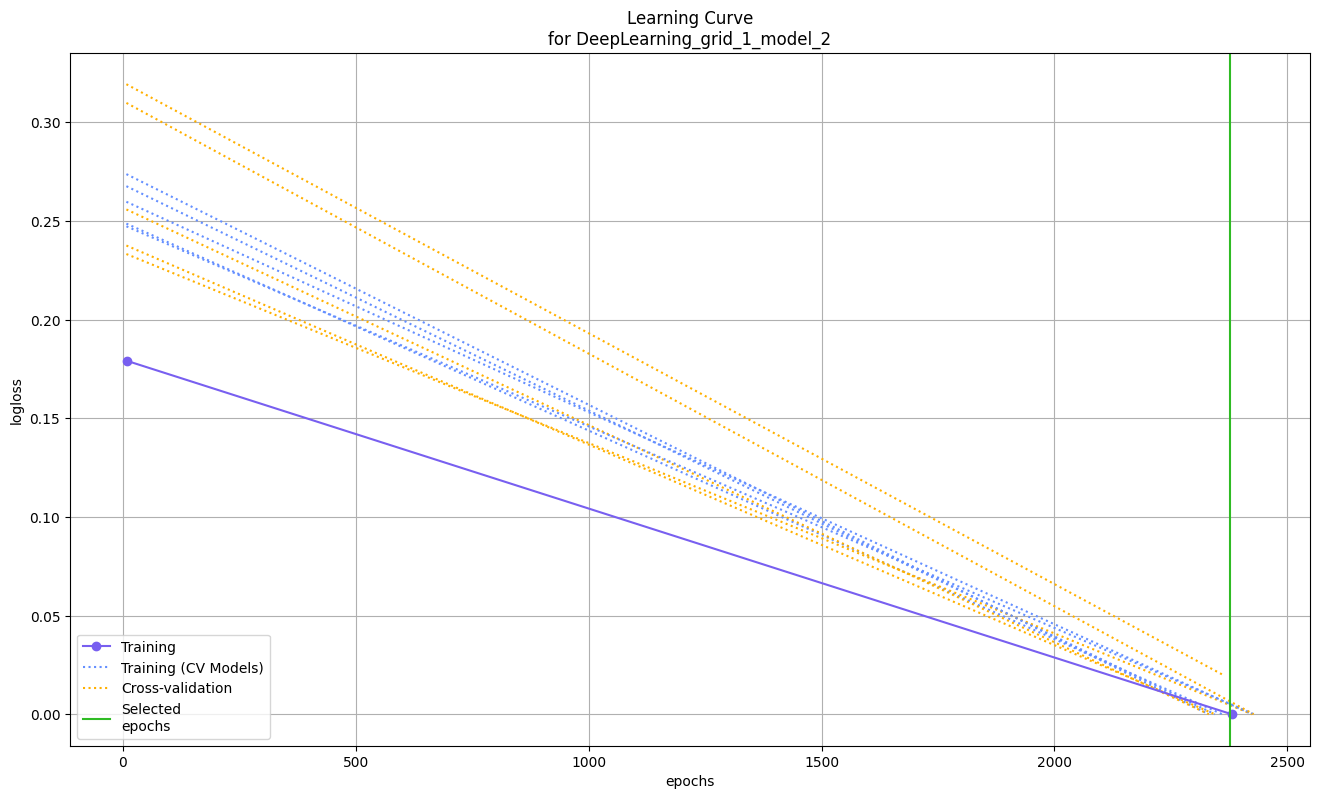

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

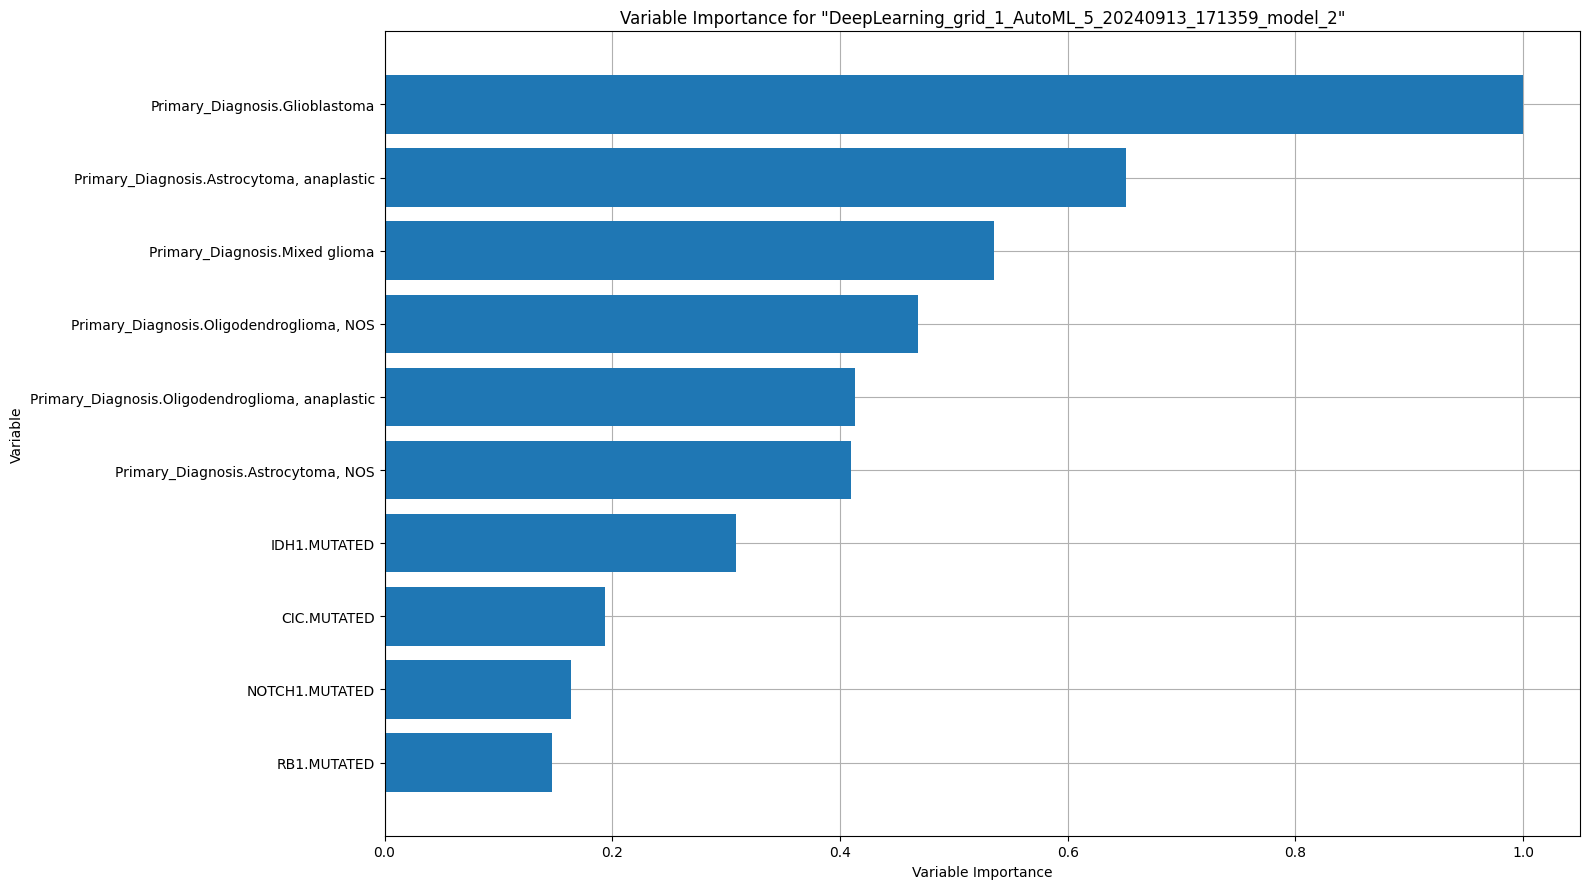

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

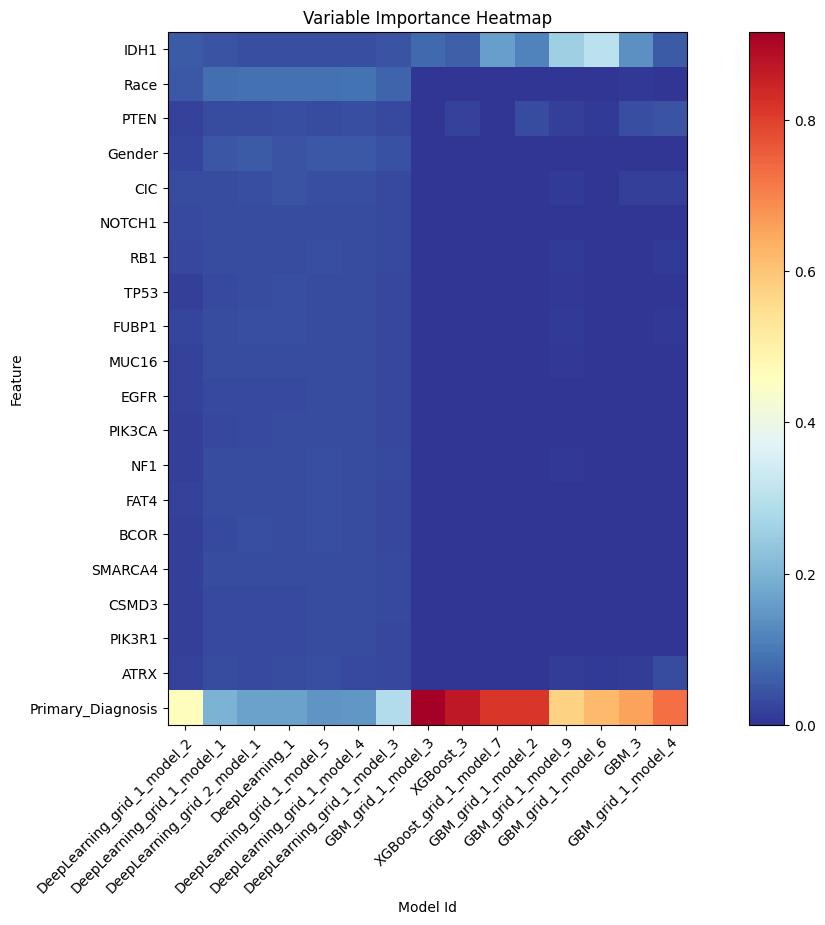

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

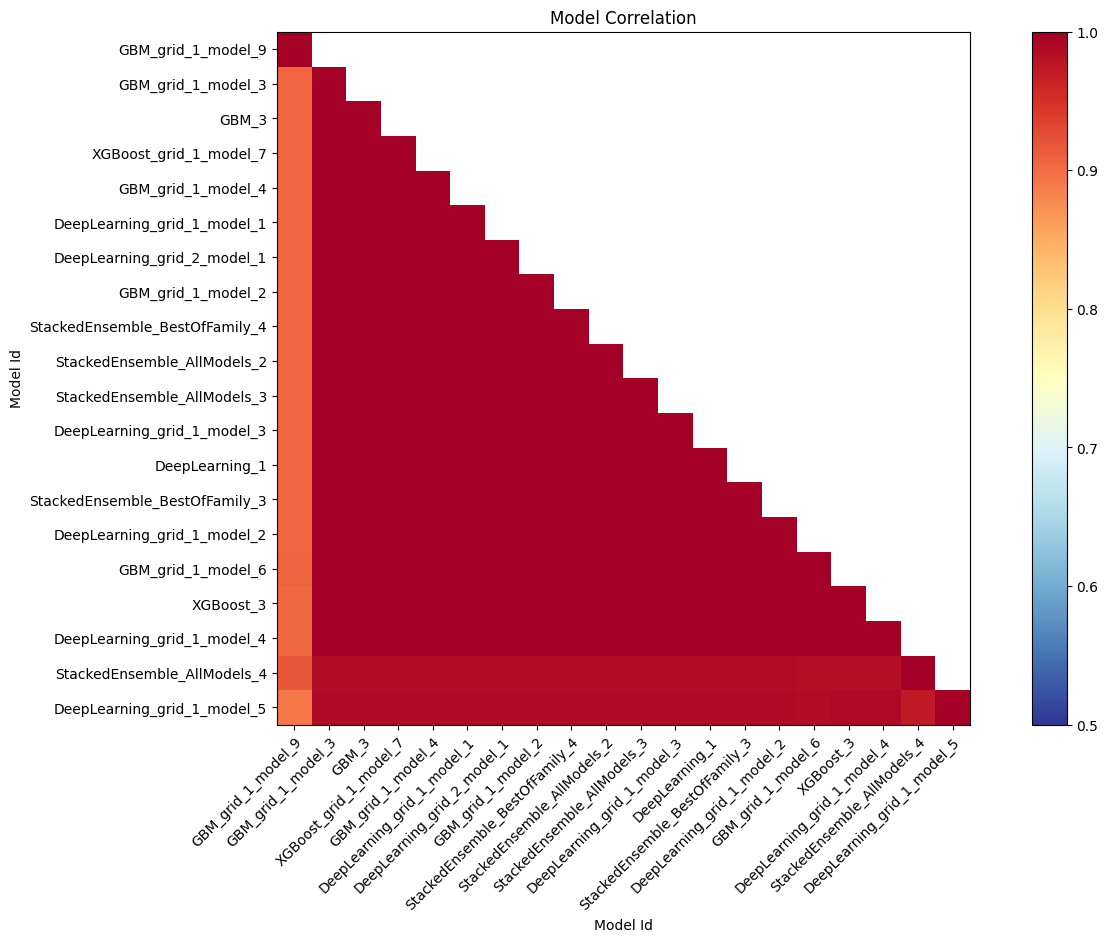

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
XGBoost_grid_1_AutoML_5_20240913_171359_model_22,1,0.009444,1,0,0.0369534,0.00136556,527,0.024188,XGBoost
GBM_4_AutoML_5_20240913_171359,1,3.408e-16,1,0,7.50638e-16,5.63457e-31,1970,0.578254,GBM
StackedEnsemble_BestOfFamily_2_AutoML_5_20240913_171359,1,3.96704e-06,1,0,4.44206e-06,1.97319e-11,756,0.574735,StackedEnsemble
GBM_grid_1_AutoML_5_20240913_171359_model_6,1,6.60194e-12,1,0,1.27854e-10,1.63467e-20,1877,0.650178,GBM
GBM_grid_1_AutoML_5_20240913_171359_model_8,1,3.57628e-15,1,0,3.61805e-15,1.30903e-29,722,0.405712,GBM
StackedEnsemble_BestOfFamily_4_AutoML_5_20240913_171359,1,0.000619297,1,0,0.0026557,7.05272e-06,523,0.548272,StackedEnsemble
GBM_grid_1_AutoML_5_20240913_171359_model_10,1,0.00259726,1,0,0.00262324,6.88141e-06,101,0.099123,GBM
XGBoost_grid_1_AutoML_5_20240913_171359_model_23,1,0.0184068,1,0,0.0461097,0.0021261,717,0.015,XGBoost
DeepLearning_grid_1_AutoML_5_20240913_171359_model_2,1,2.1466e-05,1,0,0.00045924,2.10902e-07,1578,0.017557,DeepLearning
GBM_grid_1_AutoML_5_20240913_171359_model_5,1,1.04726e-15,1,0,2.32357e-15,5.39897e-30,1533,0.647208,GBM


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## DeepLearning_grid_1_AutoML_5_20240913_171359_model_2

,GBM,LGG,Error,Rate
GBM,254.0,0.0,0.0,(0.0/254.0)
LGG,0.0,349.0,0.0,(0.0/349.0)
Total,254.0,349.0,0.0,(0.0/603.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

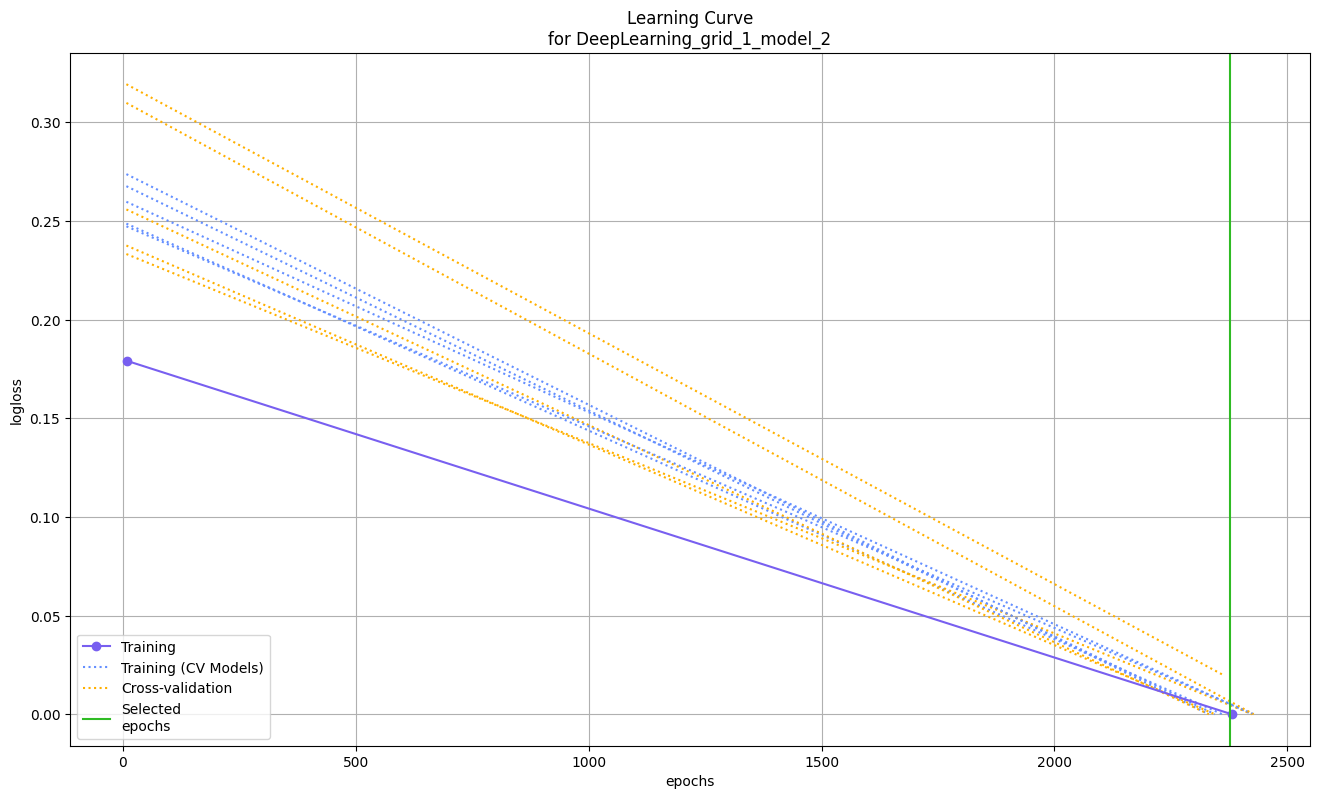

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

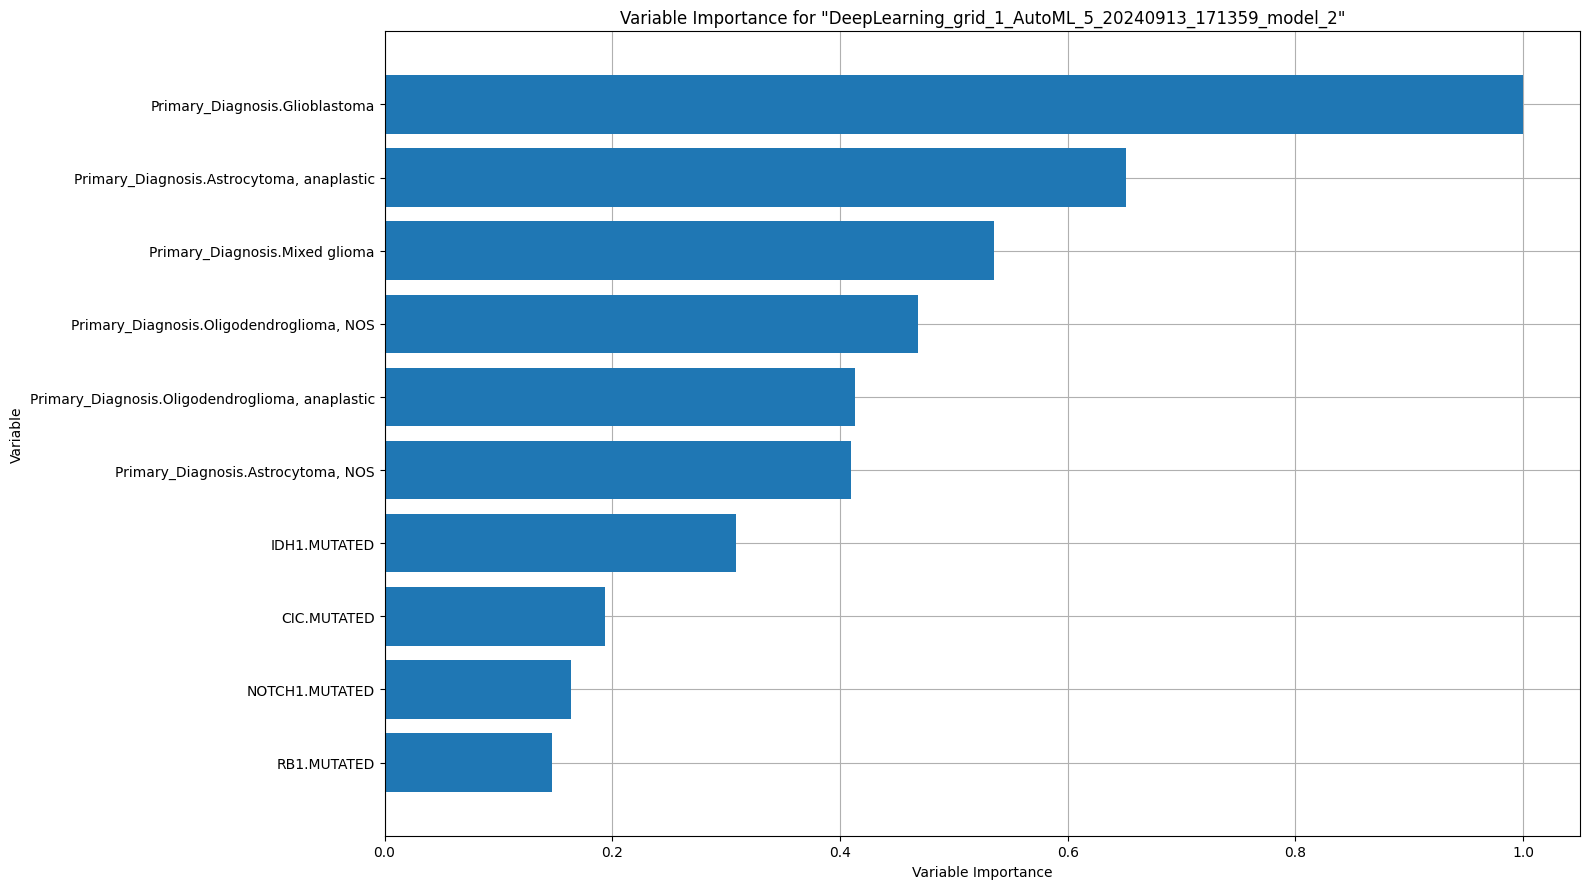

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

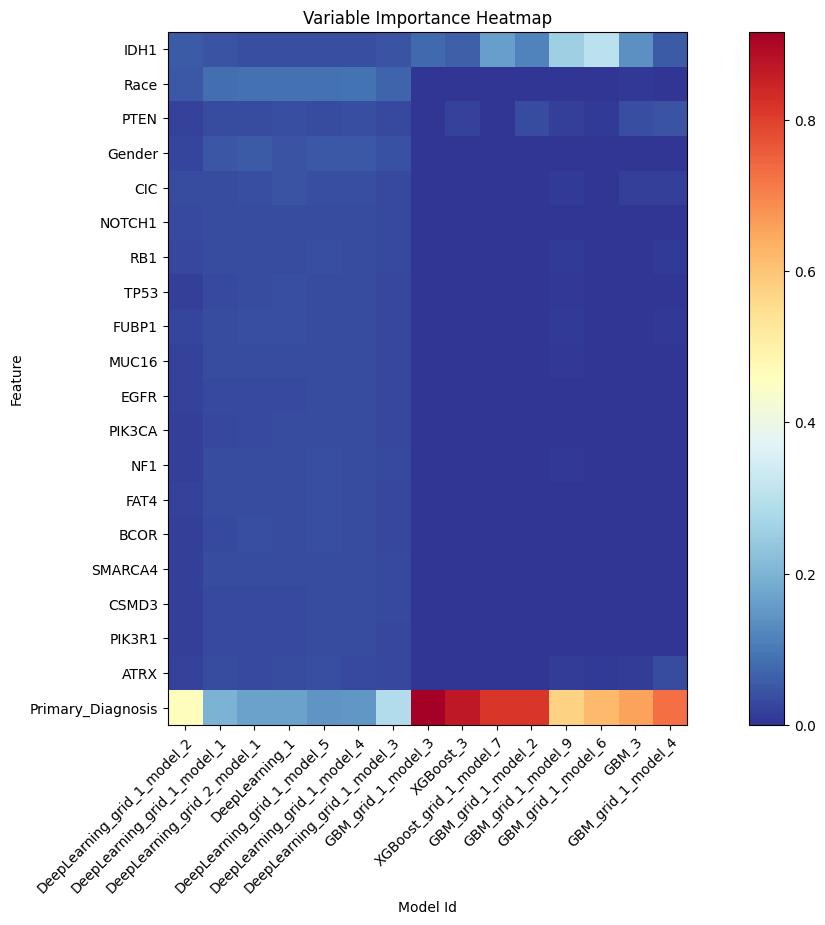

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

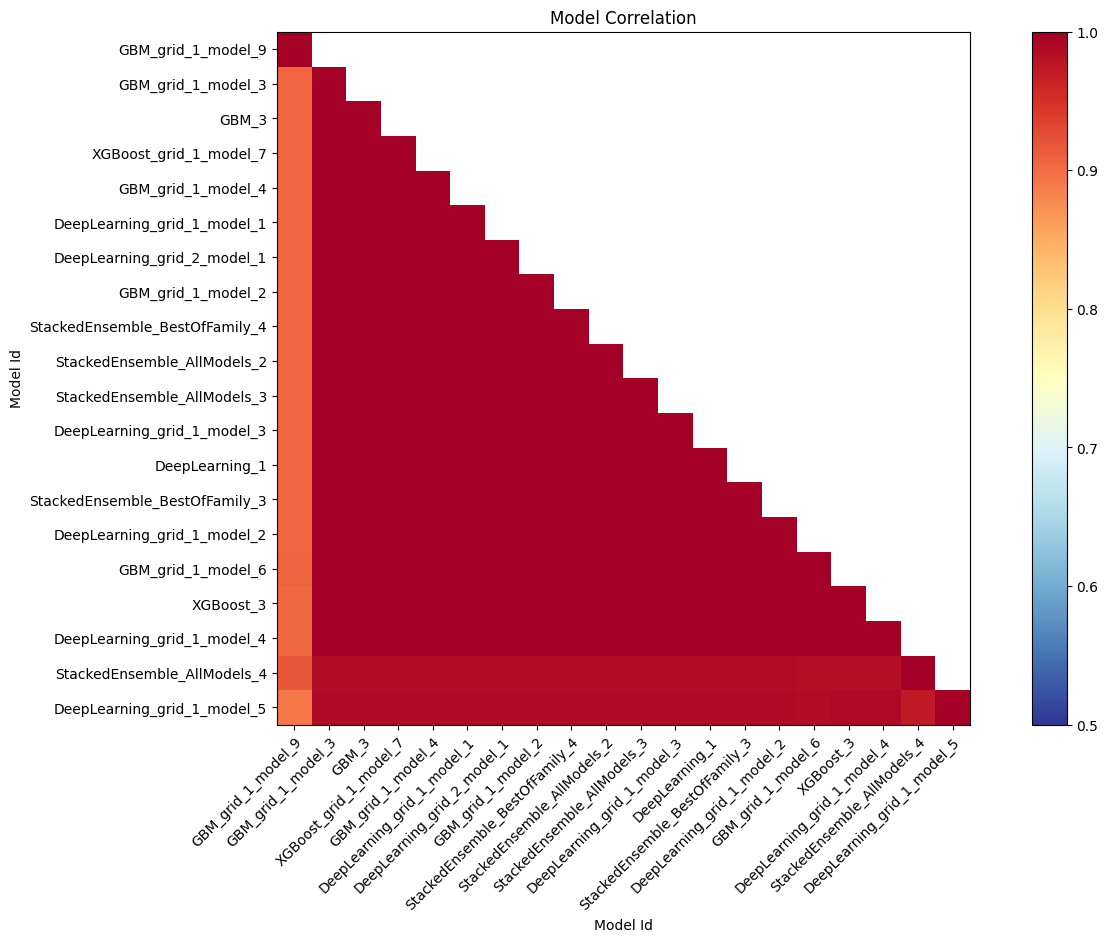

In [25]:
aml.explain(train_data, exclude_explanations=["shap_summary", "pdp"])

In [28]:
lb = aml.leaderboard
print(lb)

model_id                                                     auc     logloss     aucpr    mean_per_class_error       rmse         mse
GBM_4_AutoML_2_20240913_92834                           1         0.00891307  1                     0           0.0442678  0.00195964
DeepLearning_grid_1_AutoML_2_20240913_92834_model_2     1         0.00626627  1                     0           0.0374261  0.00140071
GBM_3_AutoML_2_20240913_92834                           1         0.00895125  1                     0           0.044327   0.00196488
GLM_1_AutoML_2_20240913_92834                           1         0.0363193   1                     0           0.057696   0.00332882
GBM_5_AutoML_2_20240913_92834                           0.999983  0.00959667  0.999988              0.00241546  0.0444265  0.00197372
DeepLearning_grid_1_AutoML_2_20240913_92834_model_1     0.999983  0.0174098   0.999988              0.00241546  0.0514884  0.00265105
GBM_1_AutoML_2_20240913_92834                           0.9999

In [9]:
lb = aml.leaderboard
print(lb)

model_id                                                      auc     logloss     aucpr    mean_per_class_error       rmse          mse
DeepLearning_grid_1_AutoML_5_20240913_171359_model_2     1         0.00404943  1                      0          0.0371412  0.00137947
StackedEnsemble_BestOfFamily_3_AutoML_5_20240913_171359  1         0.00421093  1                      0          0.0289104  0.000835811
DeepLearning_1_AutoML_5_20240913_171359                  1         0.00216024  1                      0          0.0179593  0.000322536
DeepLearning_grid_1_AutoML_5_20240913_171359_model_3     1         0.00307128  1                      0          0.0335984  0.00112885
StackedEnsemble_AllModels_3_AutoML_5_20240913_171359     1         0.0759881   1                      0          0.0818452  0.00669863
StackedEnsemble_AllModels_2_AutoML_5_20240913_171359     1         0.00484004  1                      0          0.0324081  0.00105028
DeepLearning_grid_1_AutoML_5_20240913_171359_model_4

In [10]:
test = pd.read_csv(DATA_FOLDER + "test.csv").drop(columns=["Unnamed: 0", "Case_ID"])
test = test.replace({"--": None, "not reported": None})
test = test.fillna(-1)
test["Age_at_diagnosis"] = test["Age_at_diagnosis"].apply(lambda x: int(x.split(" ")[0]) if isinstance(x, str) else x)

test = h2o.H2OFrame(test)

preds = aml.predict(test)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%


In [11]:
preds

predict,GBM,LGG
LGG,1.60568e-15,1
LGG,7.1561e-12,1
LGG,1.68153e-15,1
GBM,1,3.14796e-19
GBM,1,1.31912e-14
LGG,1.70517e-18,1
LGG,1.05512e-10,1
GBM,1,1.00573e-13
GBM,1,5.00258e-15
LGG,1.03586e-11,1


In [12]:
submission = pd.read_csv(DATA_FOLDER + "sample_submission_file.csv")
answers = preds["predict"].as_data_frame()
answers = answers.replace({"LGG": 0, "GBM": 1})
submission["Grade"] = answers
submission

/home/susbar/Documents/HSE/Master/1_year/ML/.venv/lib/python3.11/site-packages/h2o/frame.py:1981: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,Id,Grade
0,0,0
1,1,0
2,2,0
3,3,1
4,4,1
...,...,...
254,254,0
255,255,0
256,256,0
257,257,1


In [14]:
save_submission(submission, OUTPUT_FOLDER)

In [13]:
first = pd.read_csv(OUTPUT_FOLDER + "sub_20240913_094351.csv")
# second = pd.read_csv(OUTPUT_FOLDER + "sub_20240913_130441.csv")
second = submission

(first["Grade"] == second["Grade"]).sum()

np.int64(253)